## Dane energetyczne przygotowanie do pracy, wstępne sprawdzenie danych


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Acquisition and Structural Inspection

In [2]:
def load_data(filename):
    df = pd.read_csv(filename)

    print(df.shape)
    print(df.columns)
    print(df.dtypes)
    print(df.head(2))
    return df

df = load_data('../Data/entsoe_data_2024_2025.csv')

(301391, 39)
Index(['datetime', 'country', 'price', 'nuclear', 'fossil_gas', 'solar',
       'waste', 'wind_offshore', 'wind_onshore', '_biomass_actual_aggregated_',
       '_fossil_brown_coal_lignite_actual_aggregated_',
       '_fossil_coal_derived_gas_actual_aggregated_',
       '_fossil_gas_actual_aggregated_',
       '_fossil_hard_coal_actual_aggregated_',
       '_fossil_oil_actual_aggregated_',
       '_hydro_pumped_storage_actual_aggregated_',
       '_hydro_pumped_storage_actual_consumption_',
       '_hydro_run_of_river_and_poundage_actual_aggregated_',
       '_hydro_water_reservoir_actual_aggregated_',
       '_other_actual_aggregated_', '_other_renewable_actual_aggregated_',
       '_solar_actual_aggregated_', '_wind_onshore_actual_aggregated_',
       'biomass', 'energy_storage', 'fossil_brown_coal_lignite',
       'fossil_coal_derived_gas', 'fossil_hard_coal', 'fossil_oil',
       'fossil_oil_shale', 'fossil_peat', 'geothermal', 'hydro_pumped_storage',
       'hydro_run_

## 2. Temporal Data Standardization

In [3]:
df['date'] = pd.to_datetime(df['datetime'], utc=True)
df.drop('datetime', axis=1, inplace=True)

## 3. Metadata Enrichment: Country Normalization

In [6]:
country_map = {
    'AT': 'Austria',
    'BE': 'Belgium',
    'CH': 'Switzerland',
    'CZ': 'Czech Republic',
    'DE_LU': 'Germany / Luxembourg',
    'DK_1': 'Denmark (West)',
    'EE': 'Estonia',
    'ES': 'Spain',
    'FR': 'France',
    'HR': 'Croatia',
    'HU': 'Hungary',
    'IE_SEM': 'Ireland',
    'IT_NORD': 'Italy (North)',
    'LT': 'Lithuania',
    'LV': 'Latvia',
    'NL': 'Netherlands',
    'NO_3': 'Norway (Mid)',
    'PL': 'Poland',
    'PT': 'Portugal',
    'RO': 'Romania',
    'SE_4': 'Sweden (South)',
    'SI': 'Slovenia',
    'SK': 'Slovakia'
}

df['country'] = df['country'].replace(country_map)

print(df['country'].unique())

<ArrowStringArray>
[      'Czech Republic', 'Germany / Luxembourg',             'Slovakia',
               'Poland',              'Austria',              'Hungary',
               'France',                'Spain',             'Portugal',
              'Belgium',          'Netherlands',       'Denmark (West)',
        'Italy (North)',              'Croatia',             'Slovenia',
              'Ireland',               'Latvia',            'Lithuania',
              'Estonia',          'Switzerland',              'Romania',
         'Norway (Mid)',       'Sweden (South)']
Length: 23, dtype: str


## 4. Missing Value Profiling and Null Analysis

In [7]:
print(df.isnull().sum())
print(df.describe())

country                                                     0
price                                                      22
nuclear                                                170375
fossil_gas                                              32394
solar                                                   26302
waste                                                  104912
wind_offshore                                          209678
wind_onshore                                             6192
_biomass_actual_aggregated_                            288288
_fossil_brown_coal_lignite_actual_aggregated_          288288
_fossil_coal_derived_gas_actual_aggregated_            288288
_fossil_gas_actual_aggregated_                         288288
_fossil_hard_coal_actual_aggregated_                   288288
_fossil_oil_actual_aggregated_                         288288
_hydro_pumped_storage_actual_aggregated_               288288
_hydro_pumped_storage_actual_consumption_              288288
_hydro_r

In [8]:
df = df.drop(columns=['marine']) #usuwamy kolumne marine ponieważ jest ona w 100% zerowa


## 5. Per-Country Data Completeness Audit

In [9]:
missing_by_country = df.isnull().groupby(df['country']).sum()
print(missing_by_country.shape)

(23, 38)


Exporting a detailed missing data matrix to Excel for audit purposes.

In [55]:
cols_to_export = [
    'date', 'price', 'nuclear', 'fossil_gas', 'solar', 'waste',
    'wind_offshore', 'wind_onshore', 'biomass', 'energy_storage',
    'fossil_brown_coal_lignite', 'fossil_coal_derived_gas', 'fossil_hard_coal',
    'fossil_oil', 'fossil_oil_shale', 'fossil_peat', 'geothermal',
    'hydro_pumped_storage', 'hydro_run_of_river_and_poundage', 'hydro_total',
    'hydro_water_reservoir', 'other', 'other_renewable'
]
missing_by_country[cols_to_export].to_excel('braki_danych_wg_krajow.xlsx')

Plik 'braki_danych_wg_krajow.xlsx' został wygenerowany!


Cross-referencing _actual_aggregated_ columns with base features to identify overlaps.

In [10]:
agg_cols = [c for c in df.columns if '_actual_aggregated_' in c]

print("Suma wartości poza PL:", df[df['country'] != 'Poland'][agg_cols].notna().sum().sum())

df_pl = df[df['country'] == 'Poland']

for agg in agg_cols:
    base = agg[1:-19]
    if base not in df_pl.columns:
        continue

    mask = df_pl[base].notna() & df_pl[agg].notna()
    overlap = mask.sum()

    diff = (df_pl.loc[mask, base] - df_pl.loc[mask, agg]).abs().sum() if overlap > 0 else 0

    only_base = (df_pl[base].notna() & df_pl[agg].isna()).sum()
    only_agg = (df_pl[agg].notna() & df_pl[base].isna()).sum()

    print(f"{base:25} | wspólne: {overlap:<5} (różnica: {diff:.0f}) | tylko base: {only_base:<5} | tylko agg: {only_agg}")

Suma wartości poza PL: 0
biomass                   | wspólne: 13103 (różnica: 3918860) | tylko base: 0     | tylko agg: 0
fossil_brown_coal_lignite | wspólne: 13103 (różnica: 48495120) | tylko base: 0     | tylko agg: 0
fossil_coal_derived_gas   | wspólne: 13103 (różnica: 1788472) | tylko base: 0     | tylko agg: 0
fossil_gas                | wspólne: 13103 (różnica: 26403138) | tylko base: 0     | tylko agg: 0
fossil_hard_coal          | wspólne: 13103 (różnica: 81996460) | tylko base: 0     | tylko agg: 0
fossil_oil                | wspólne: 13103 (różnica: 2796876) | tylko base: 0     | tylko agg: 0
hydro_pumped_storage      | wspólne: 13103 (różnica: 1622520) | tylko base: 0     | tylko agg: 0
hydro_run_of_river_and_poundage | wspólne: 13103 (różnica: 2025649) | tylko base: 0     | tylko agg: 0
hydro_water_reservoir     | wspólne: 13103 (różnica: 628888) | tylko base: 0     | tylko agg: 0
other                     | wspólne: 13103 (różnica: 5708447) | tylko base: 0     | tylko agg:

Case study of Poland’s generation data to verify the nature of "aggregated" suffixes.

In [14]:
def plot_aggregated_vs_base(df, country_name='Poland', date_col='date', cols_to_check=None):
    if cols_to_check is None:
        cols_to_check = [
            '_biomass_actual_aggregated_',
            '_fossil_brown_coal_lignite_actual_aggregated_',
            '_fossil_coal_derived_gas_actual_aggregated_',
            '_fossil_gas_actual_aggregated_',
            '_fossil_hard_coal_actual_aggregated_',
            '_fossil_oil_actual_aggregated_',
            '_hydro_pumped_storage_actual_aggregated_',
            '_hydro_pumped_storage_actual_consumption_',
            '_hydro_run_of_river_and_poundage_actual_aggregated_',
            '_hydro_water_reservoir_actual_aggregated_',
            '_other_actual_aggregated_',
            '_other_renewable_actual_aggregated_',
            '_solar_actual_aggregated_',
            '_wind_onshore_actual_aggregated_'
        ]

    df_filtered = df[df['country'] == country_name].copy()
    df_filtered = df_filtered.sort_values(date_col)

    if df_filtered.empty:
        print(country_name)
        return

    for agg_col in cols_to_check:
        if agg_col.endswith('_actual_aggregated_'):
            base_col = agg_col[1:-19]
        elif agg_col.endswith('_actual_consumption_'):
            base_col = agg_col[1:-20]
        else:
            base_col = agg_col

        plt.figure(figsize=(15, 4))
        if base_col in df_filtered.columns:
            plt.plot(df_filtered[date_col], df_filtered[base_col],
                     label=f'{base_col}', color='blue', alpha=0.6, linewidth=1.5)

        if agg_col in df_filtered.columns:
            plt.plot(df_filtered[date_col], df_filtered[agg_col],
                     label=f'{agg_col}', color='red', alpha=0.6, linewidth=1.5)

        plt.title(f'Verification [{country_name}]: {base_col} vs {agg_col}', fontsize=12)
        plt.xlabel('Data')
        plt.ylabel('Power generation [MW]')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.5)

        plt.show()

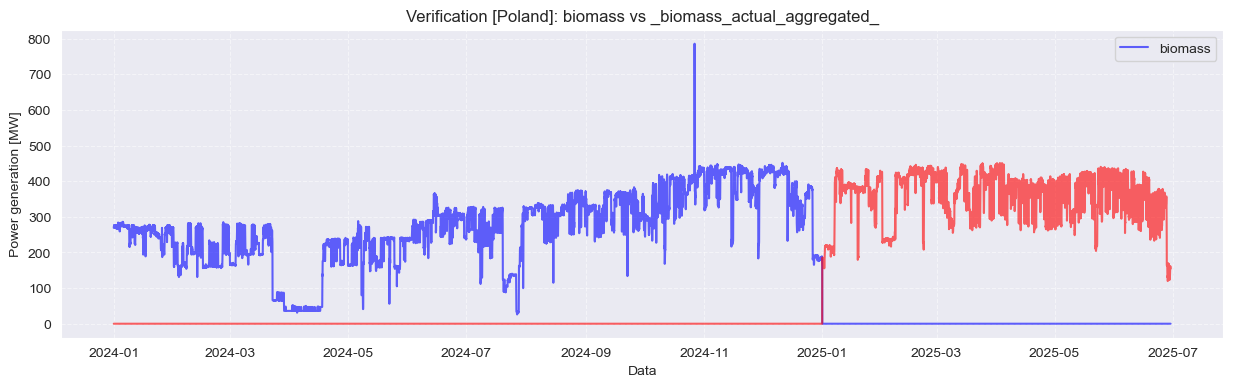

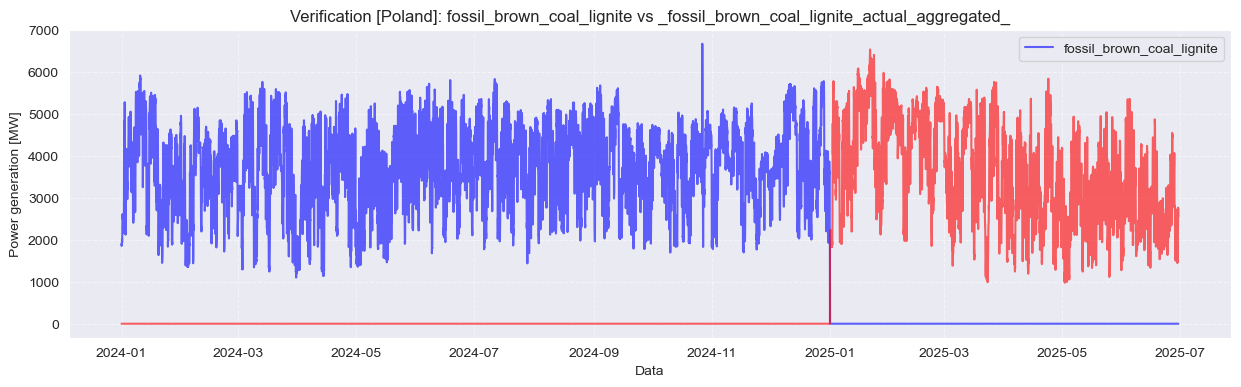

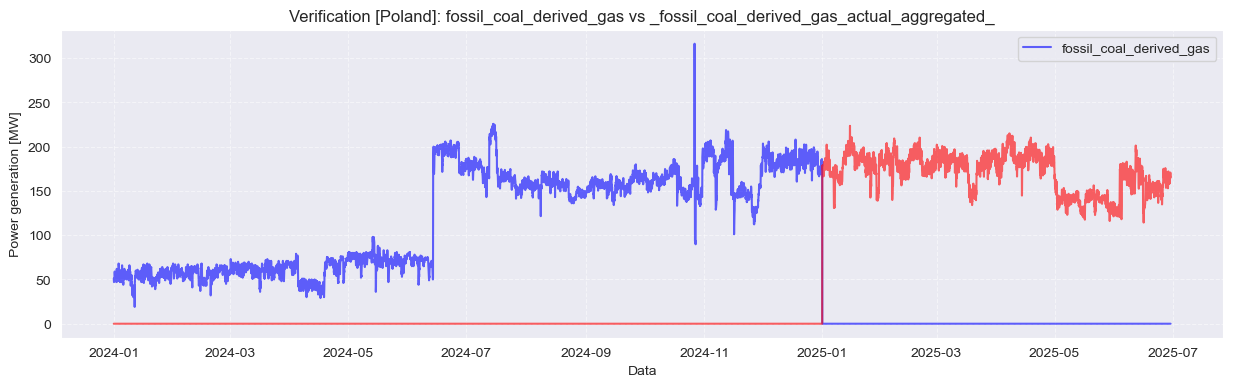

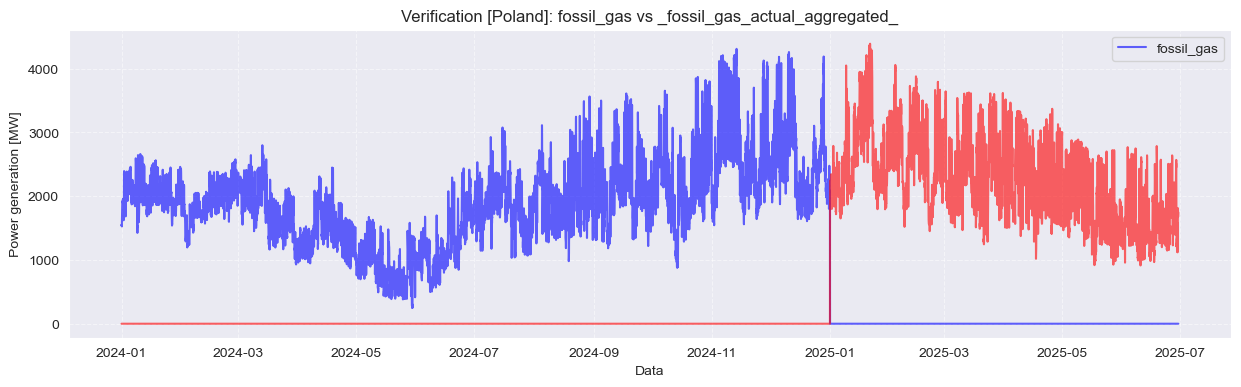

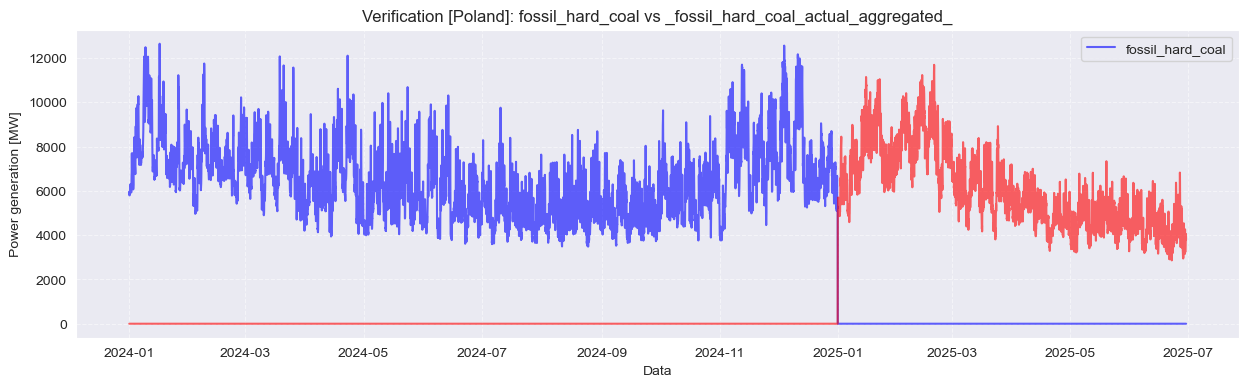

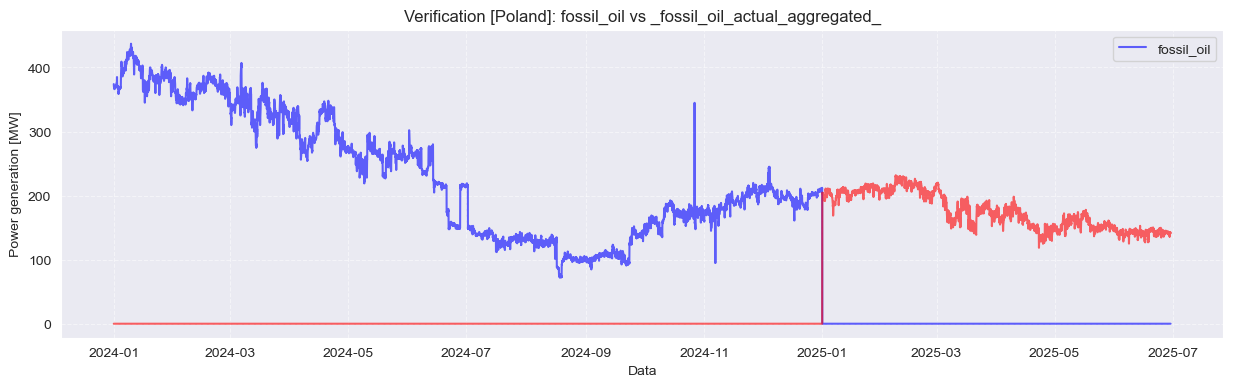

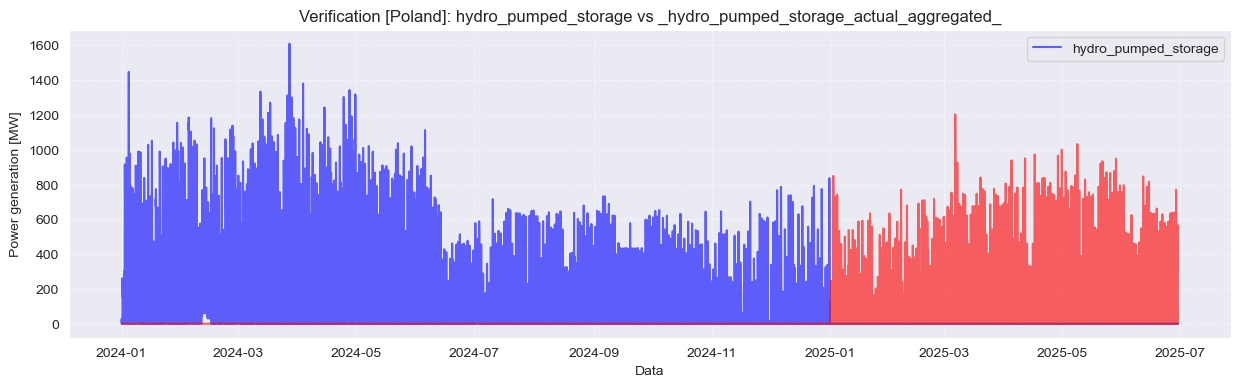

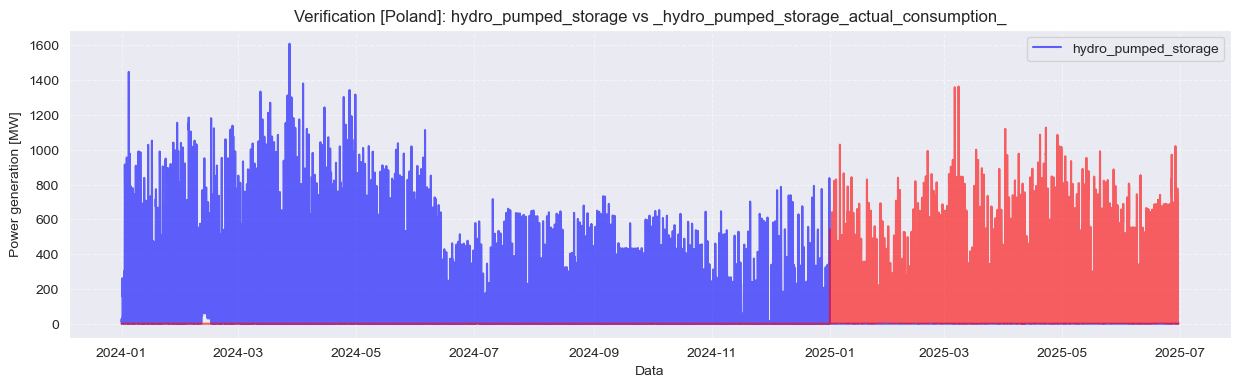

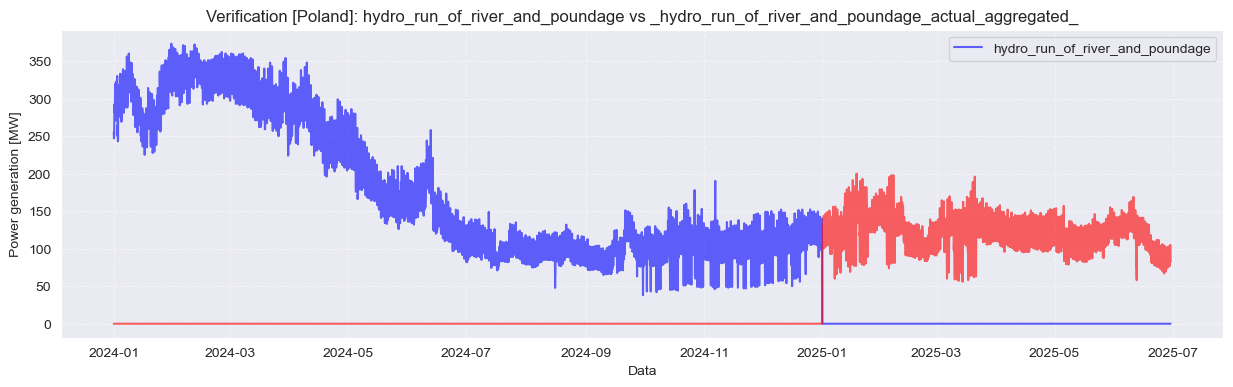

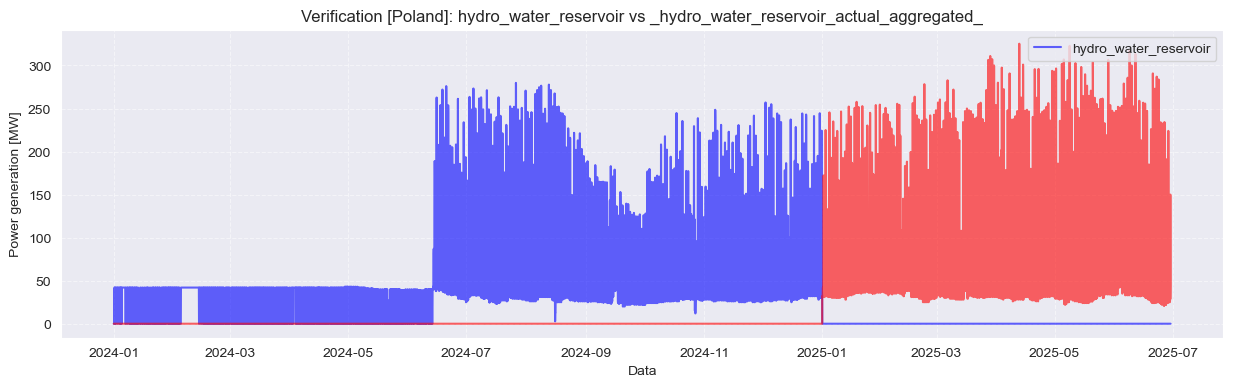

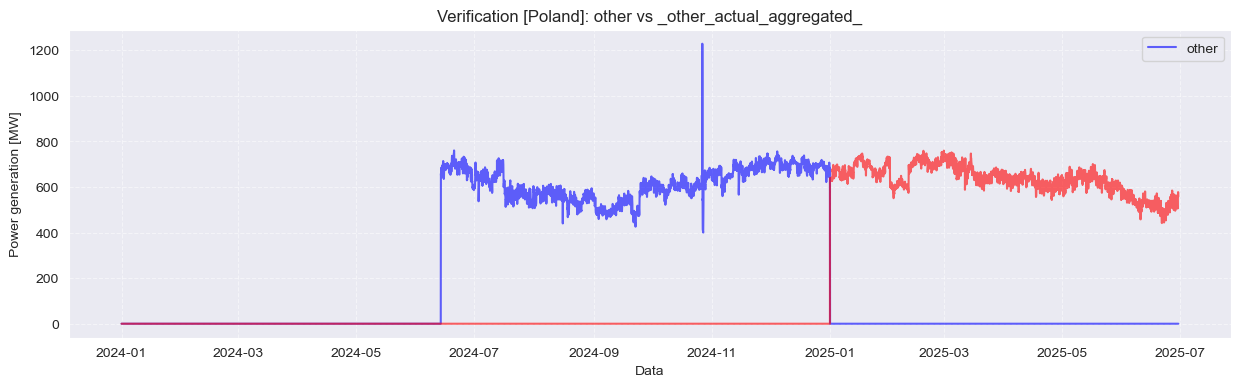

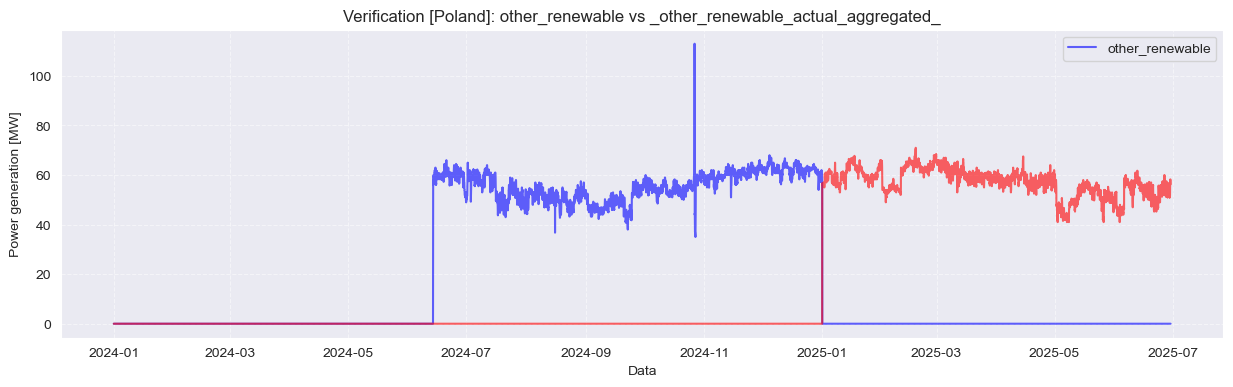

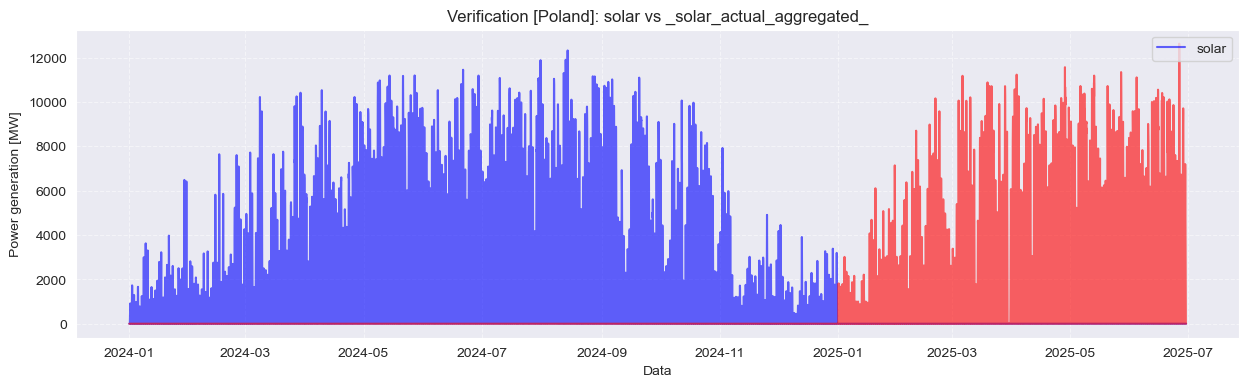

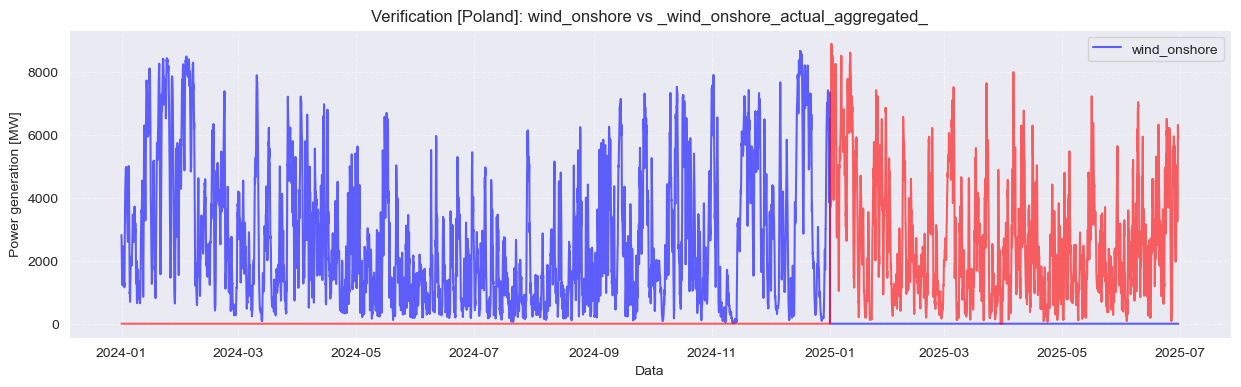

In [15]:
plot_aggregated_vs_base(df)

Merging redundant columns and performing dimensionality reduction by removing obsolete features.

In [19]:
agg_cols = [col for col in df.columns if col.endswith('_actual_aggregated_')]

for agg_col in agg_cols:
    base_col = agg_col[1:-19]

    if base_col in df.columns:
        df[base_col] = df[base_col].add(df[agg_col], fill_value=0)

df.drop(columns=agg_cols, inplace=True)

print(len(agg_cols))

13


Identification and removal of duplicate records.

In [16]:
print("Number of full duplicates:", df.duplicated().sum())
print("Duplicates for country-time pairs:", df.duplicated(subset=['date', 'country']).sum())

Number of full duplicates: 0
Duplicates for country-time pairs: 0


Applying per-country linear interpolation to fill gaps in time-series data.

In [ ]:
print(df.isnull().sum())

In [27]:
df = df.sort_values(by=['country', 'date'])

cols_to_interpolate = [col for col in df.columns if col not in ['date', 'country']]

df[cols_to_interpolate] = df.groupby('country')[cols_to_interpolate].transform(lambda x: x.interpolate(method='linear', limit=24))

print(df.isnull().sum())

country                                           0
price                                             0
nuclear                                      170351
fossil_gas                                    31813
solar                                         26207
waste                                        104831
wind_offshore                                209663
wind_onshore                                   5605
_hydro_pumped_storage_actual_consumption_    288287
biomass                                       39311
energy_storage                               248975
fossil_brown_coal_lignite                    196559
fossil_coal_derived_gas                      222767
fossil_hard_coal                             110437
fossil_oil                                   123541
fossil_oil_shale                             275183
fossil_peat                                  267685
geothermal                                   222767
hydro_pumped_storage                          97333
hydro_run_of

## 6. Temporal Feature Engineering
Extracting cyclical features: Hour of the day, Day of the week, Month, and Weekend indicators.

In [18]:
df['date'] = pd.to_datetime(df['date'], utc=True)

df['hour'] = df['date'].dt.hour
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df['season'] = (df['month'] % 12 + 3) // 3

print(df[['date', 'hour', 'day_of_week', 'is_weekend', 'season']].head())

                           date  hour  day_of_week  is_weekend  season
52416 2023-12-31 23:00:00+00:00    23            6           1       1
52417 2024-01-01 00:00:00+00:00     0            0           0       1
52418 2024-01-01 01:00:00+00:00     1            0           0       1
52419 2024-01-01 02:00:00+00:00     2            0           0       1
52420 2024-01-01 03:00:00+00:00     3            0           0       1


Serializing the cleaned dataset to a processed file format (Parquet)

In [20]:
df.to_parquet('../Data/cleaned_europe_energy.parquet', index=False)

## 7. Advanced Data Visualization and Insight Discovery

In [21]:
df2024 = df[df['date'].dt.year == 2024].copy()
df2025 = df[df['date'].dt.year == 2025].copy()
print("Początek:", df['date'].min())
print("Koniec:  ", df['date'].max())

Początek: 2023-12-31 23:00:00+00:00
Koniec:   2025-06-29 22:00:00+00:00


Price Profiling: Generating monthly average hourly electricity price charts for 2024 across all European markets.

In [ ]:
global_means = df2024.groupby(['country', 'month', 'hour'])['price'].mean()
global_vmin = global_means.min()
global_vmax = global_means.max()

kraje = df2024['country'].unique()

for kraj in kraje:
    df_kraj = df2024[df2024['country'] == kraj]
    pivot = df_kraj.pivot_table(values='price', index='hour', columns='month', aggfunc='mean')

    plt.figure(figsize=(10, 6))

    sns.heatmap(pivot, cmap='RdYlGn_r', annot=True, fmt=".0f",
                vmin=global_vmin, vmax=global_vmax,
                cbar_kws={'label': '€ / MWh'})

    plt.title(f'{kraj}')
    plt.xlabel('Month')
    plt.ylabel('Hour of the day')
    plt.gca().invert_yaxis()

    plt.show()

Generates a line graph of average electricity prices for the entire year and 4 separate graphs broken down by season for each country.

In [23]:
def plot_seasonal_prices(df):
    df_plot = df.copy()
    seasons = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'}

    if 'season_name' not in df_plot.columns:
        df_plot['season_name'] = df_plot['season'].map(seasons)

    avg_year = df_plot.groupby('country')['price'].mean()

    plt.figure(figsize=(14, 4))
    plt.plot(avg_year.index, avg_year.values, marker='o', color='black', linewidth=2)
    plt.title('Average annual electricity price in Europe')
    plt.ylabel('Price [€/MWh]')
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.show()

    colors = {'Winter': 'teal', 'Spring': 'orange', 'Summer': 'royalblue', 'Autumn': 'orchid'}

    for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
        avg_season = df_plot[df_plot['season_name'] == season].groupby('country')['price'].mean()

        plt.figure(figsize=(14, 4))
        plt.plot(avg_season.index, avg_season.values, marker='o', color=colors[season], linewidth=2)
        plt.title(f'Average electricity price - {season}')
        plt.ylabel('Price [€/MWh]')

        plt.ylim(0, 130)
        plt.grid(alpha=0.3)
        plt.xticks(rotation=45)
        plt.show()

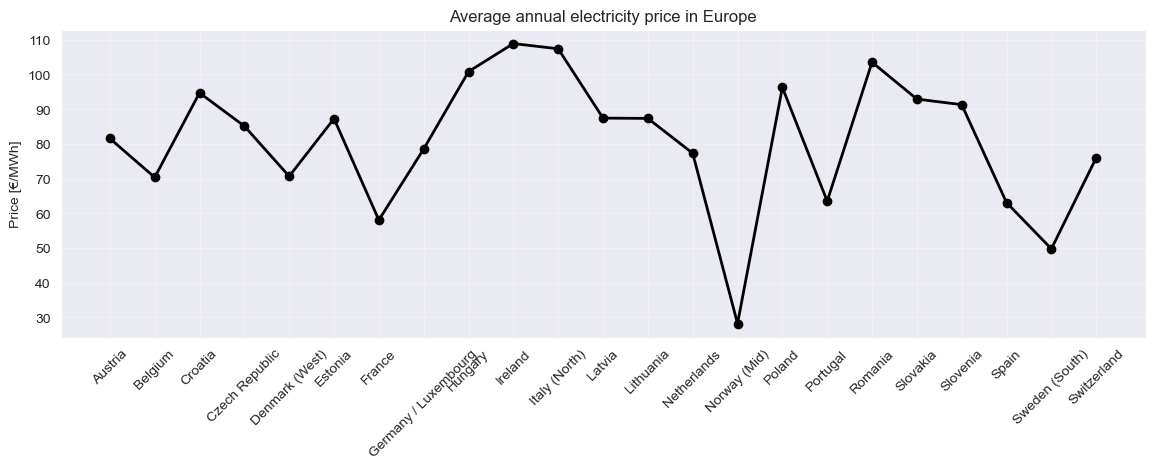

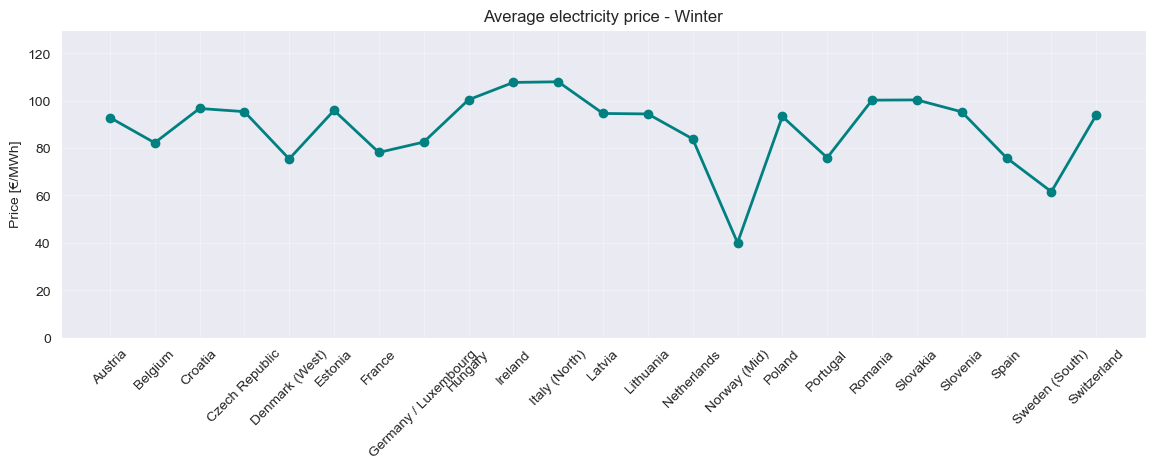

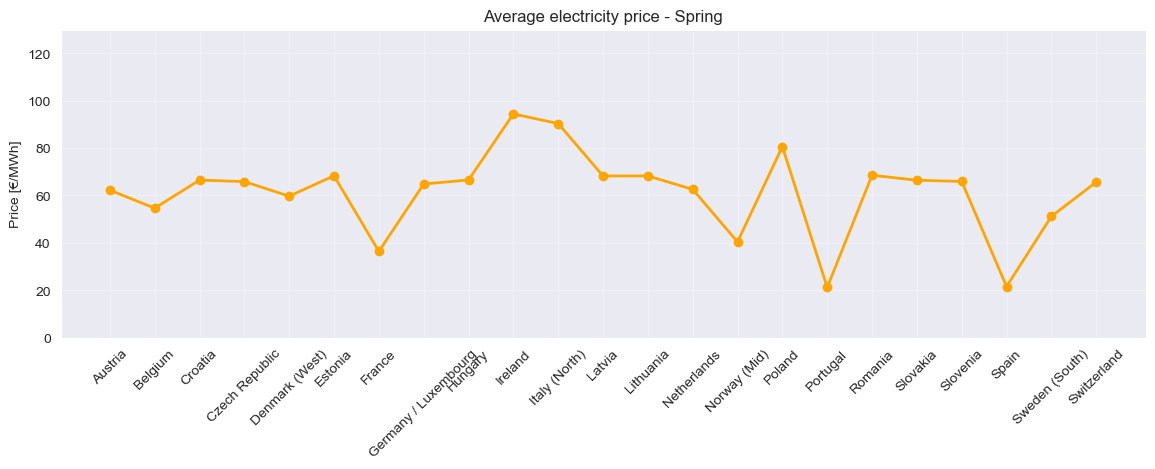

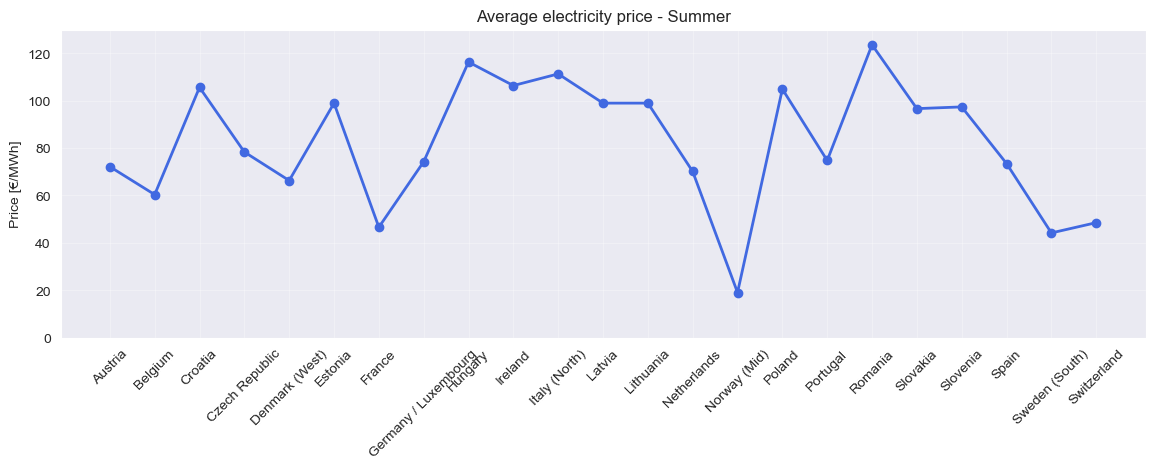

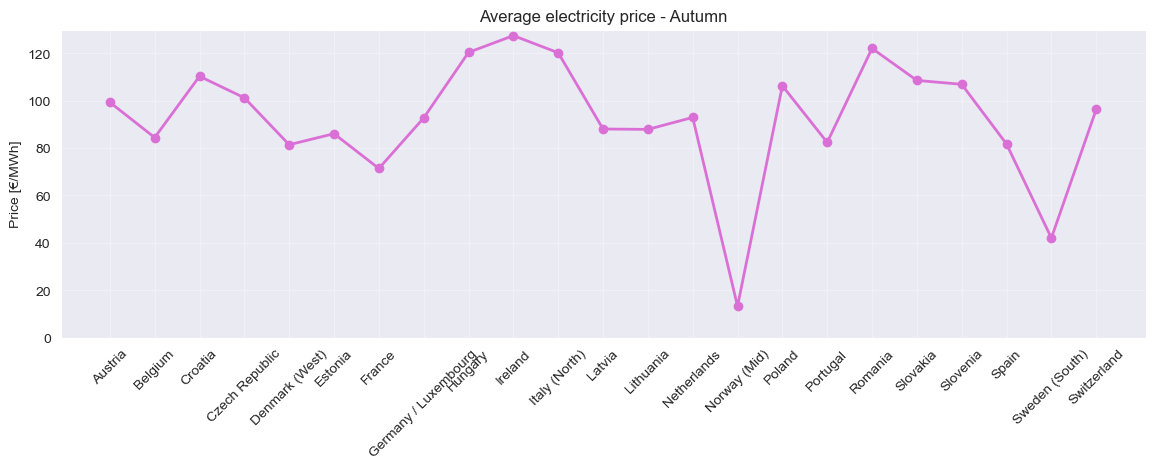

In [24]:
plot_seasonal_prices(df2024)

##

Generates a stacked bar chart for each country showing it's monthly energy production mix.

In [25]:
def plot_monthly_energy_mix(df):
    technical_columns = ['date', 'country', 'price', 'hour', 'month', 'day_of_week', 'is_weekend', 'season', 'season_name', 'hydro_total']

    energy_sources = [col for col in df.columns if col not in technical_columns]

    monthly_production = df.groupby(['country', 'month'])[energy_sources].sum().reset_index()

    countries = monthly_production['country'].unique()

    for country in countries:
        df_country = monthly_production[monthly_production['country'] == country].set_index('month')[energy_sources]

        active_sources = df_country.columns[(df_country.sum() > 0)]
        df_country = df_country[active_sources]

        df_country.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')
        plt.title(f'Monthly Energy Mix - {country}')
        plt.xlabel('Month')
        plt.ylabel('Energy [MWh]')

        plt.legend(title='Sources', bbox_to_anchor=(1.01, 1), loc='upper left')

        plt.xticks(rotation=0)
        plt.grid(axis='y', alpha=0.3)
        plt.show()

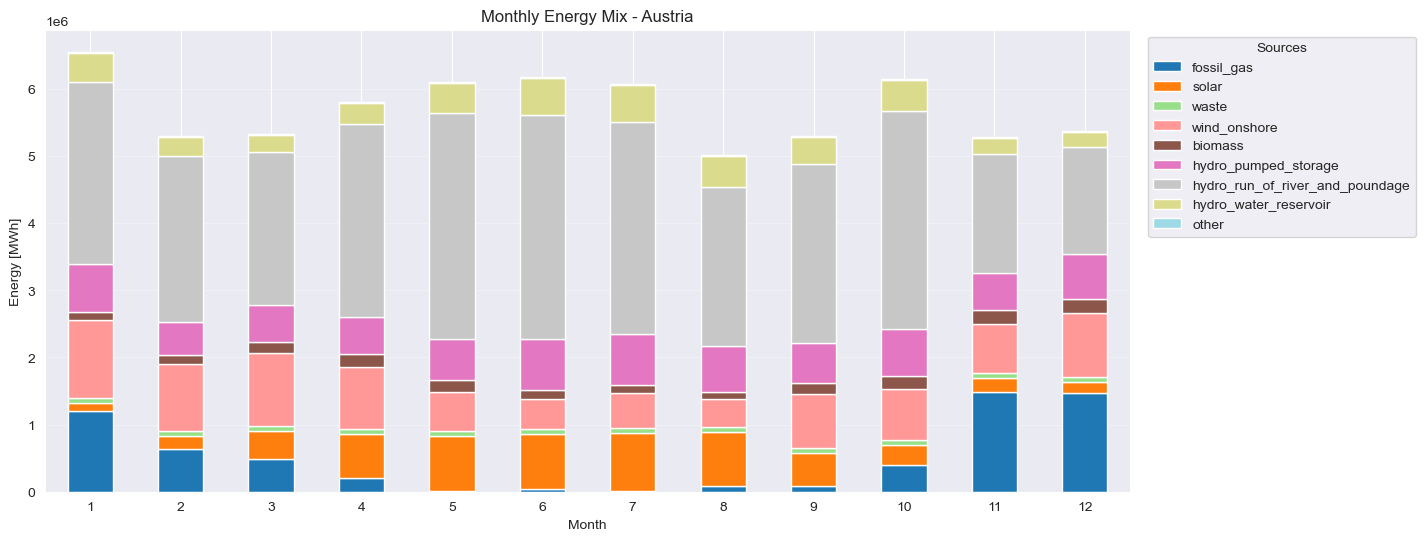

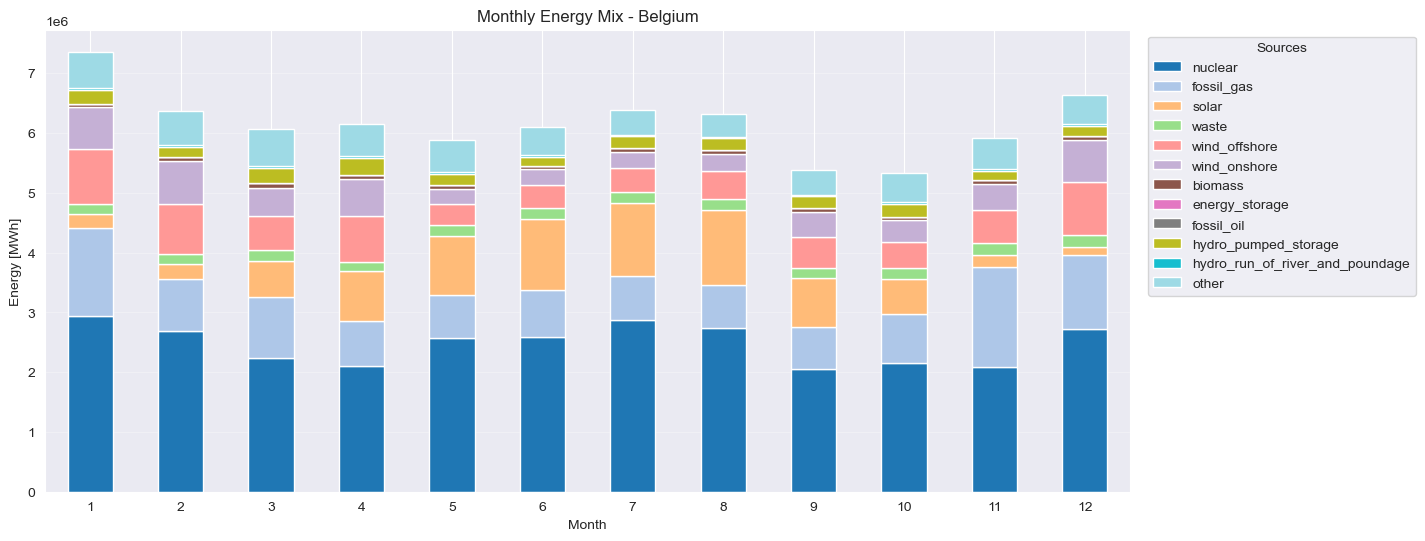

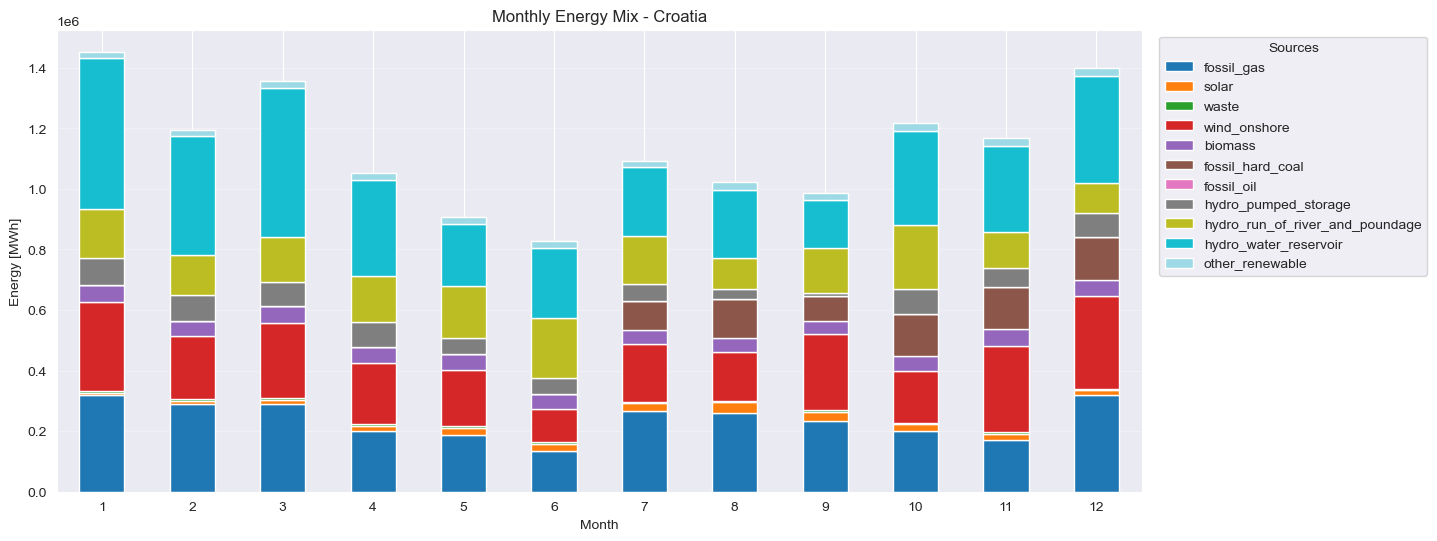

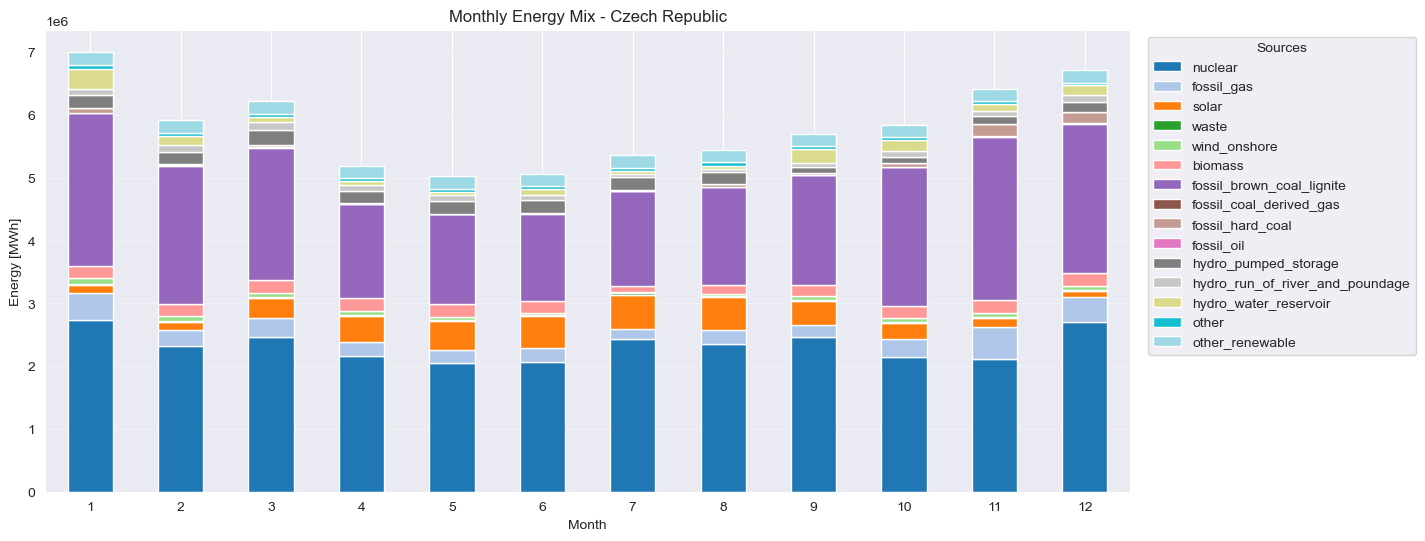

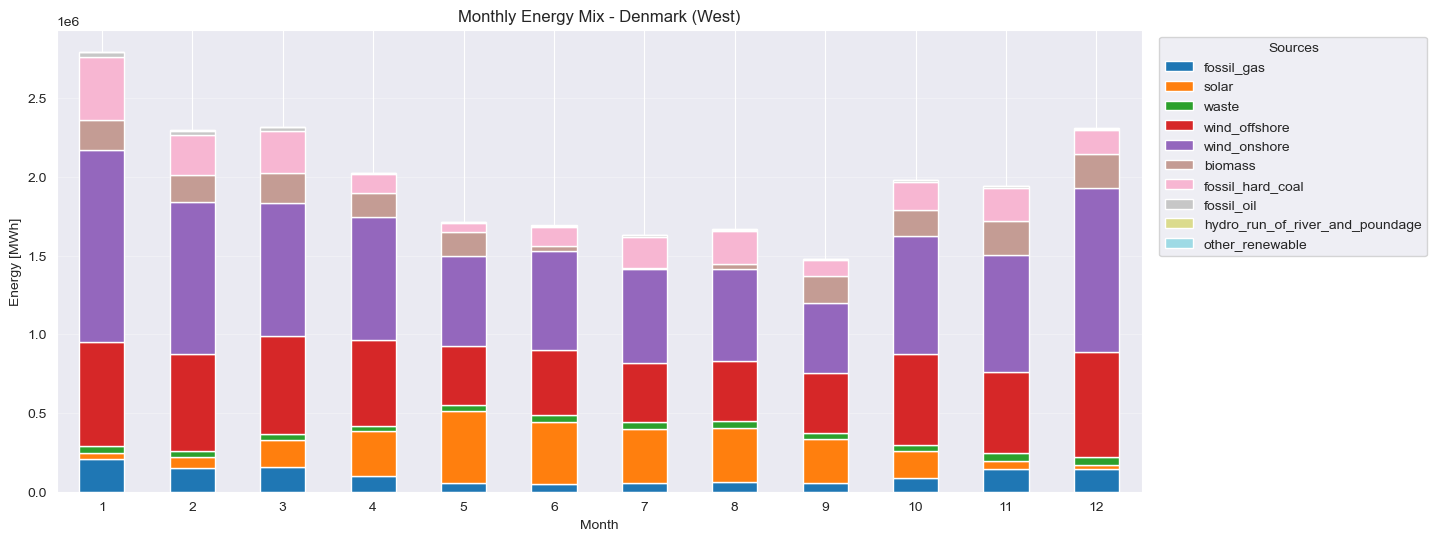

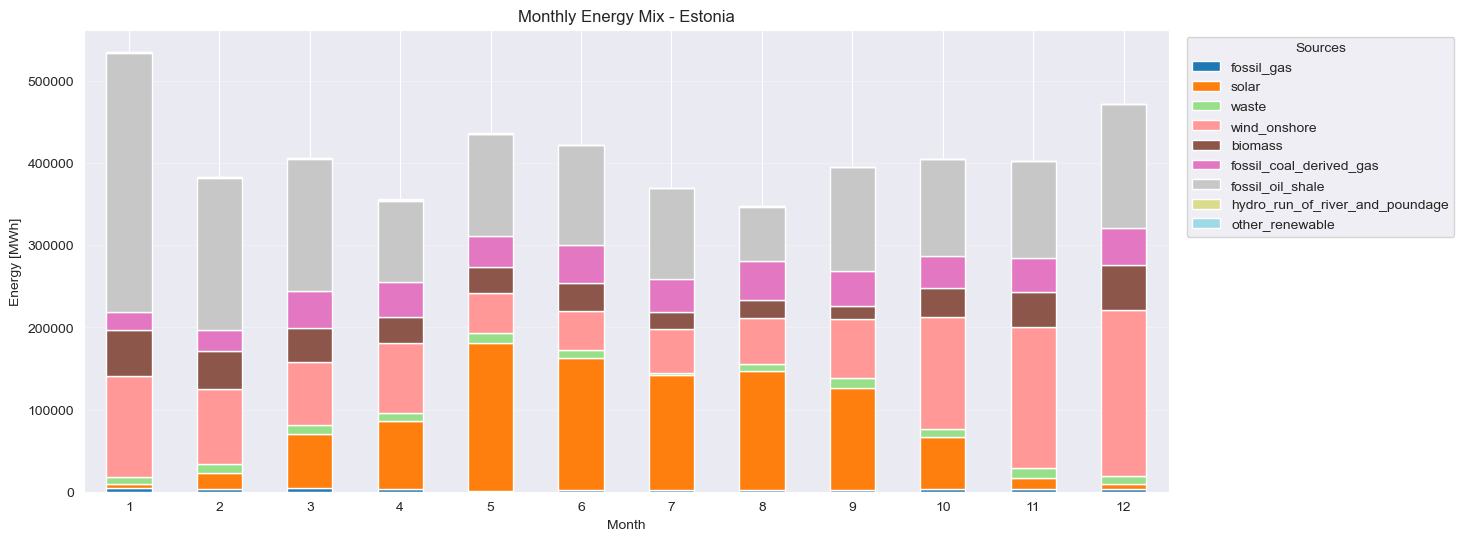

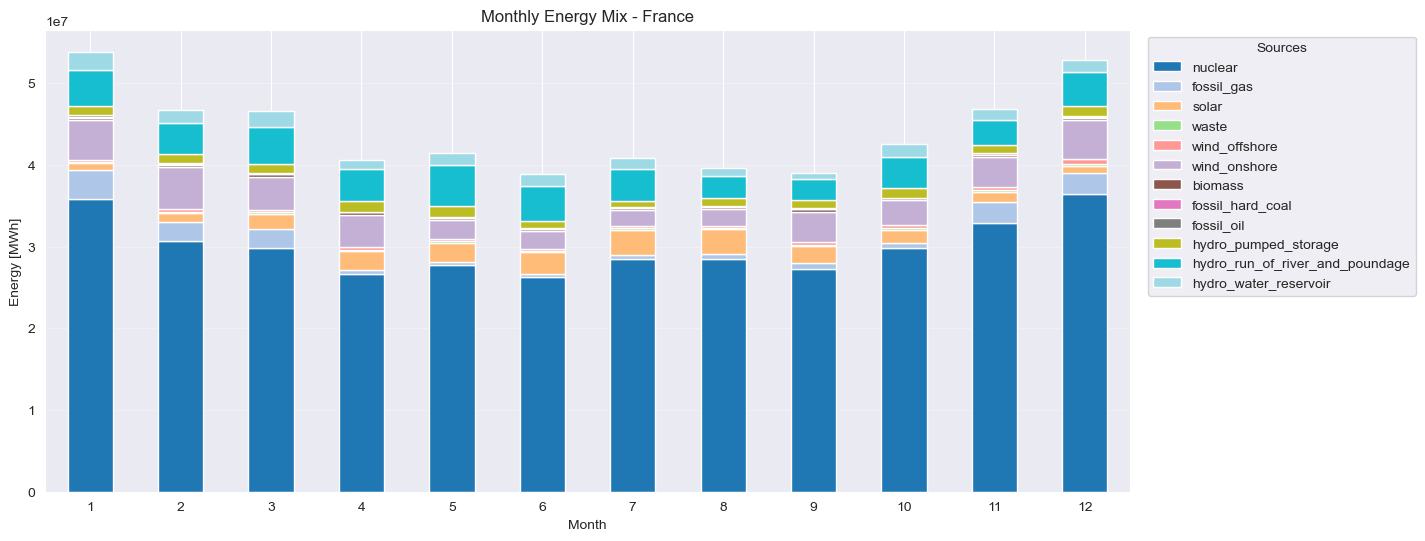

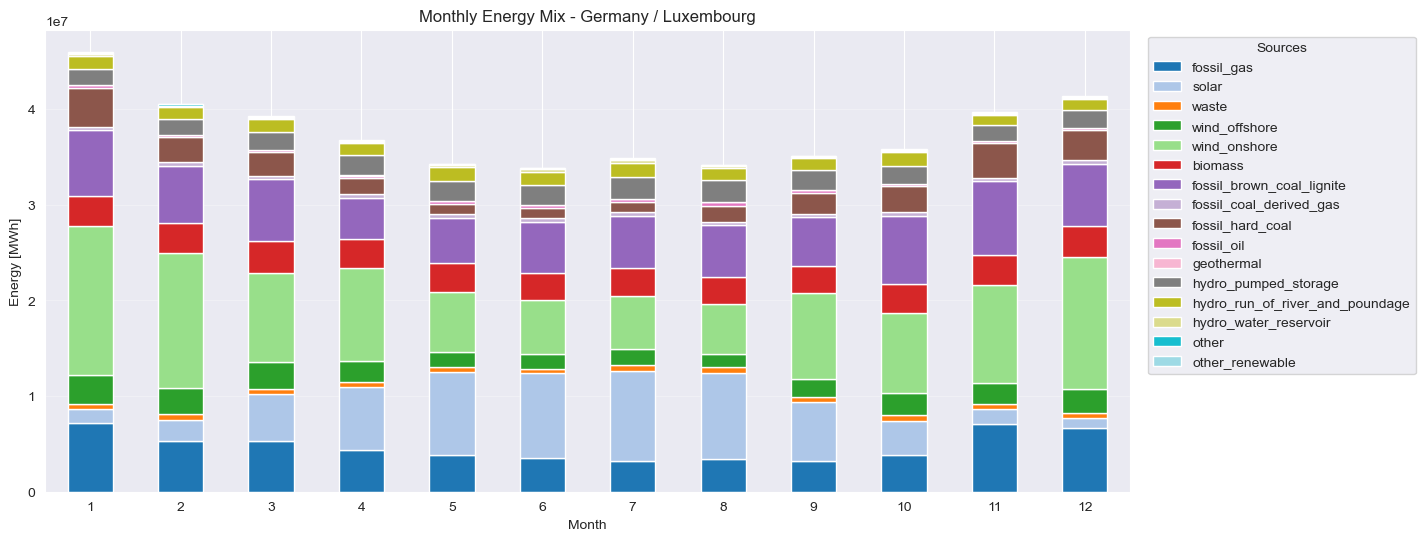

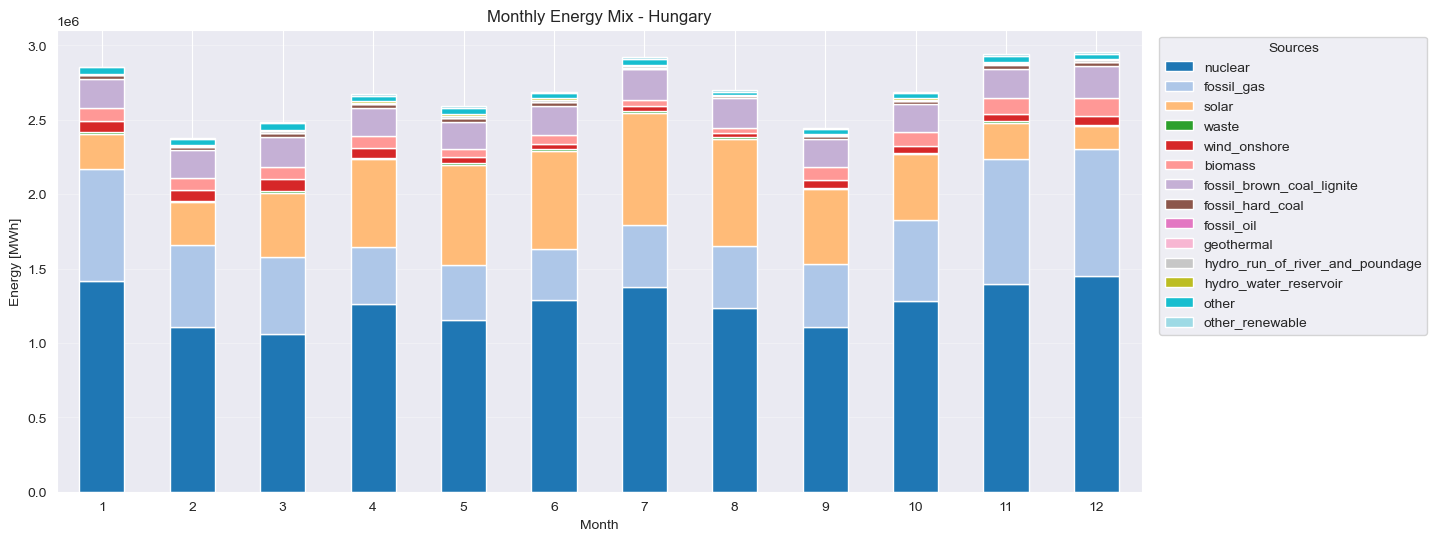

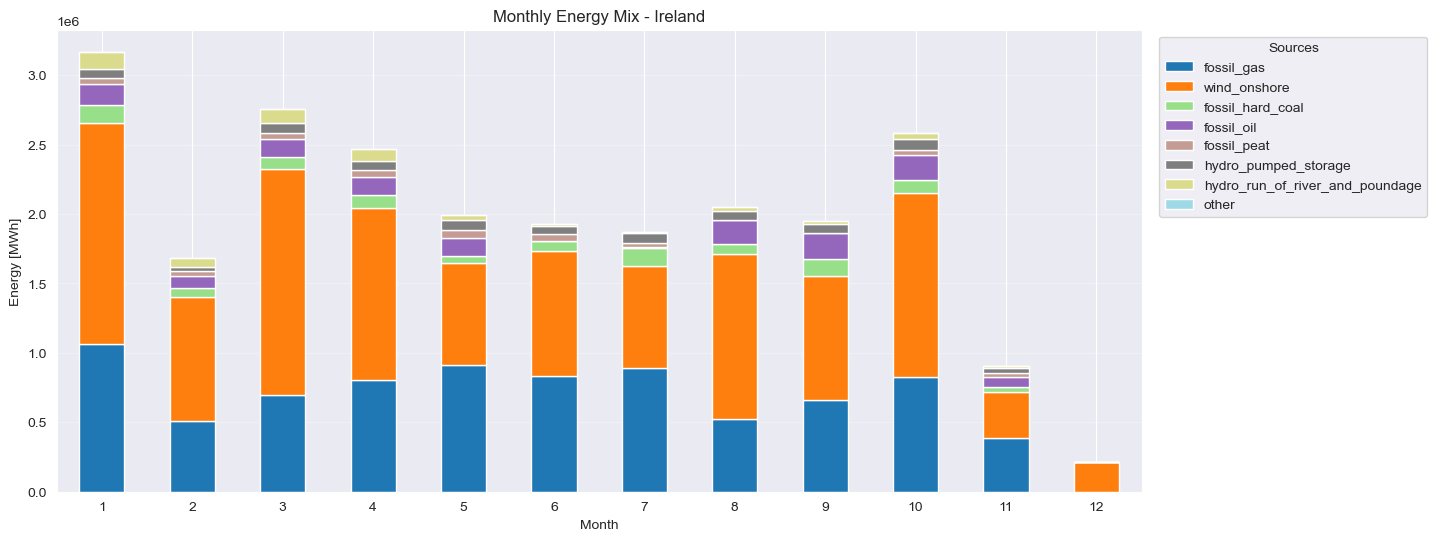

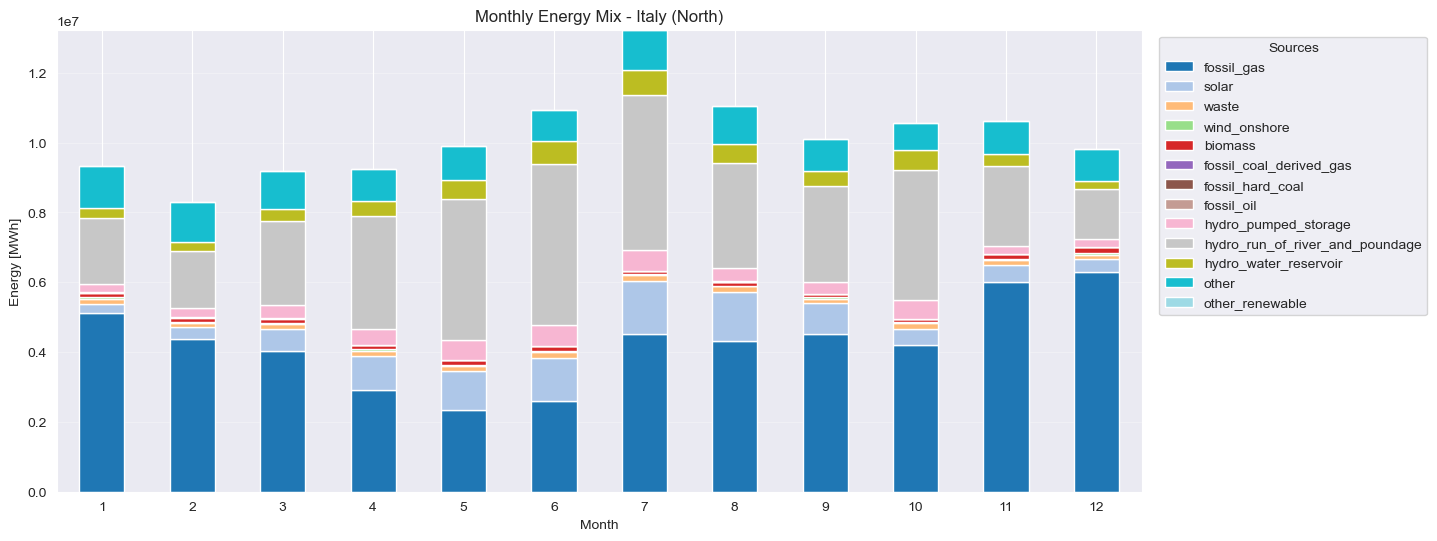

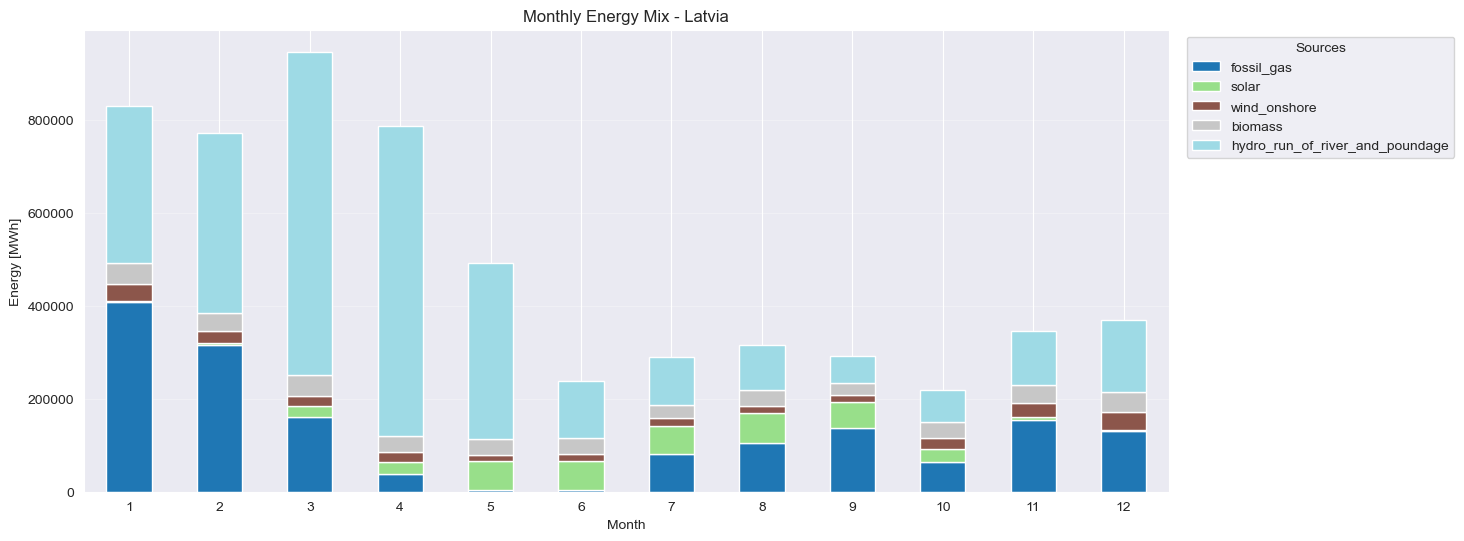

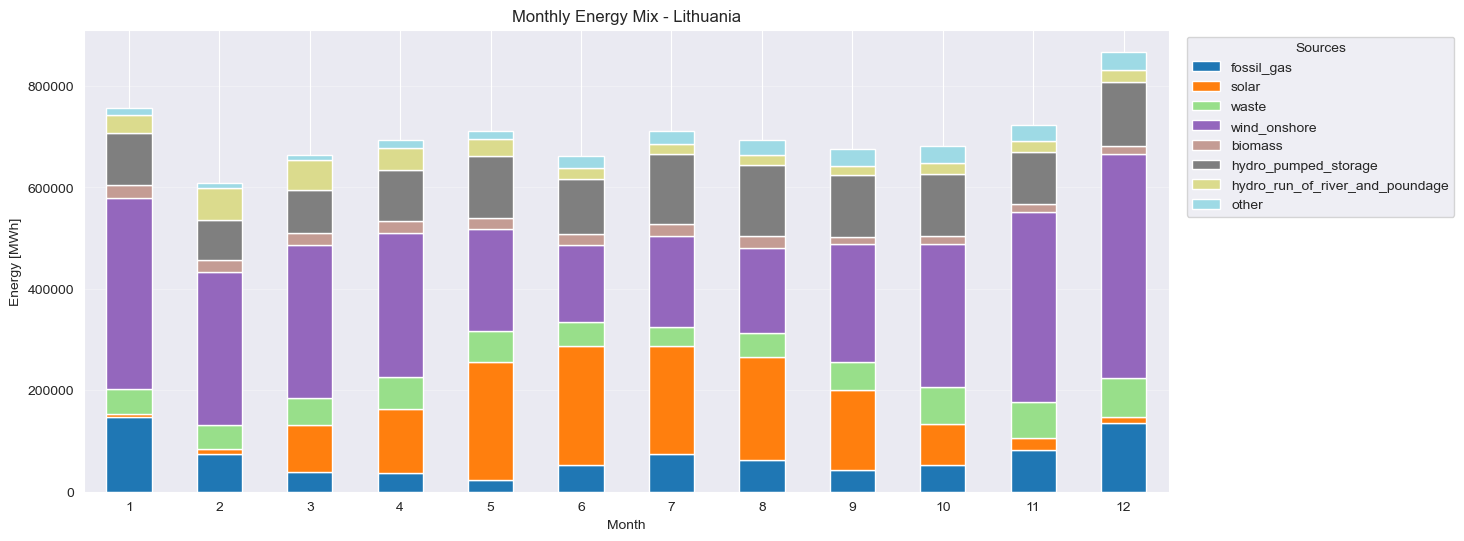

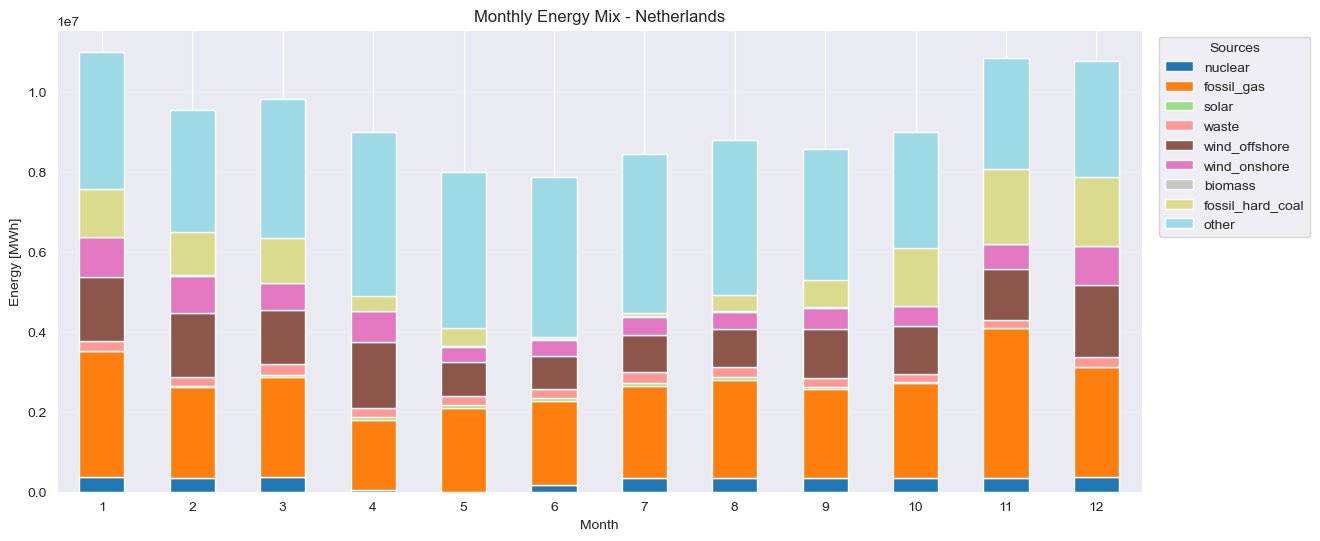

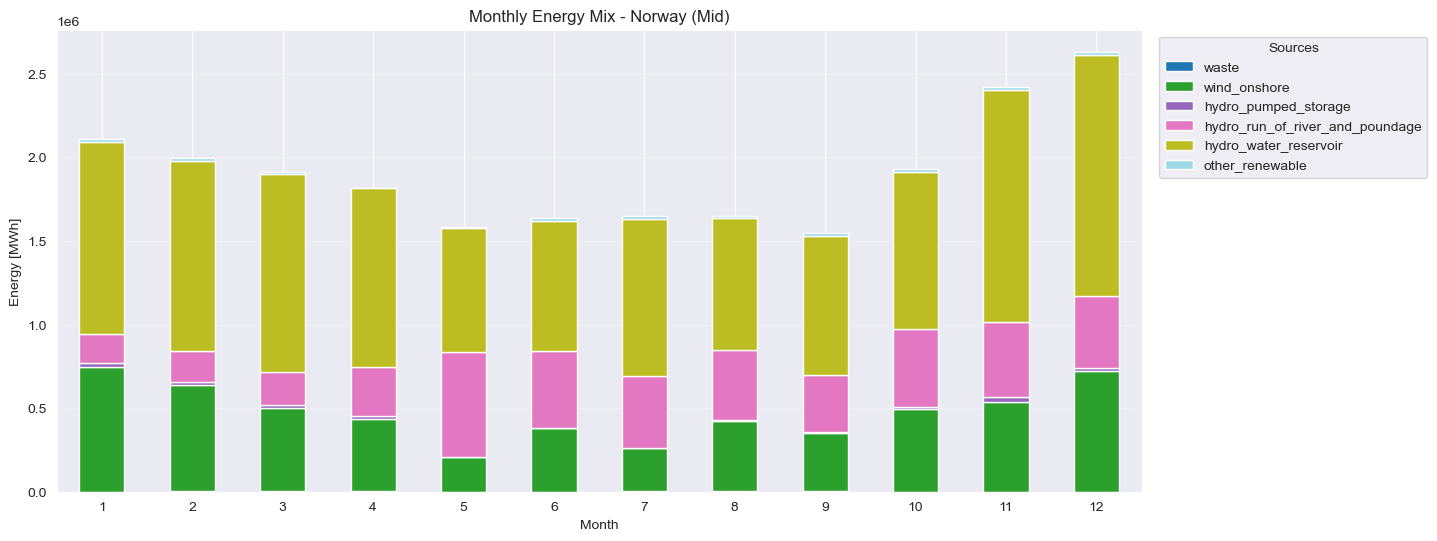

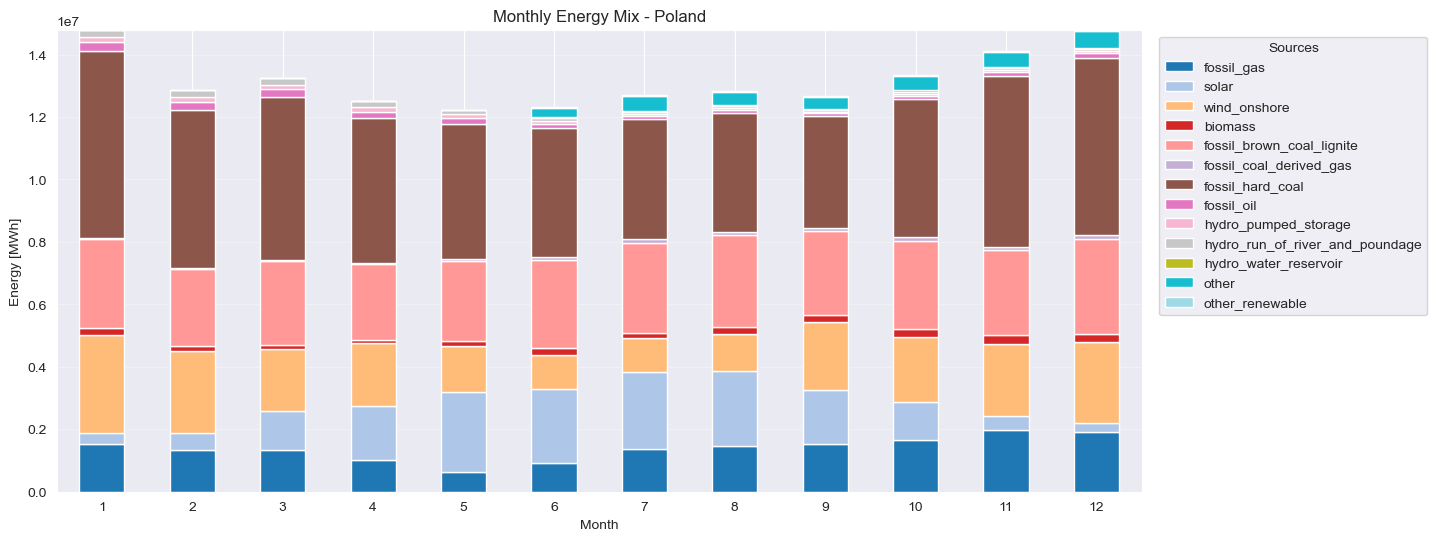

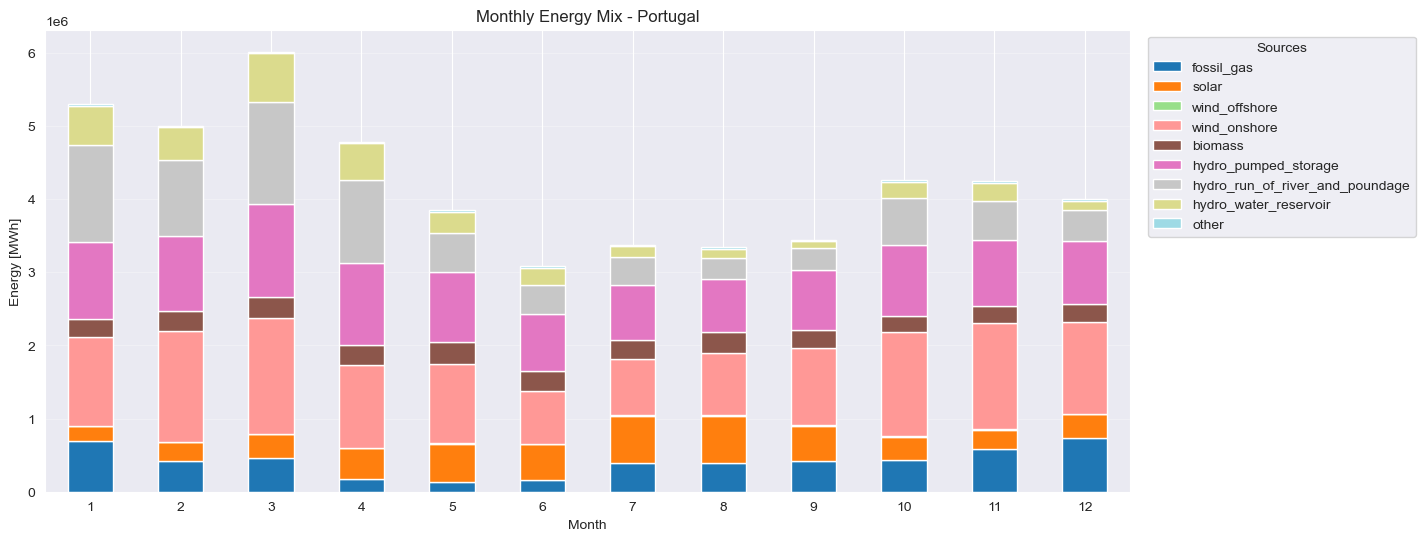

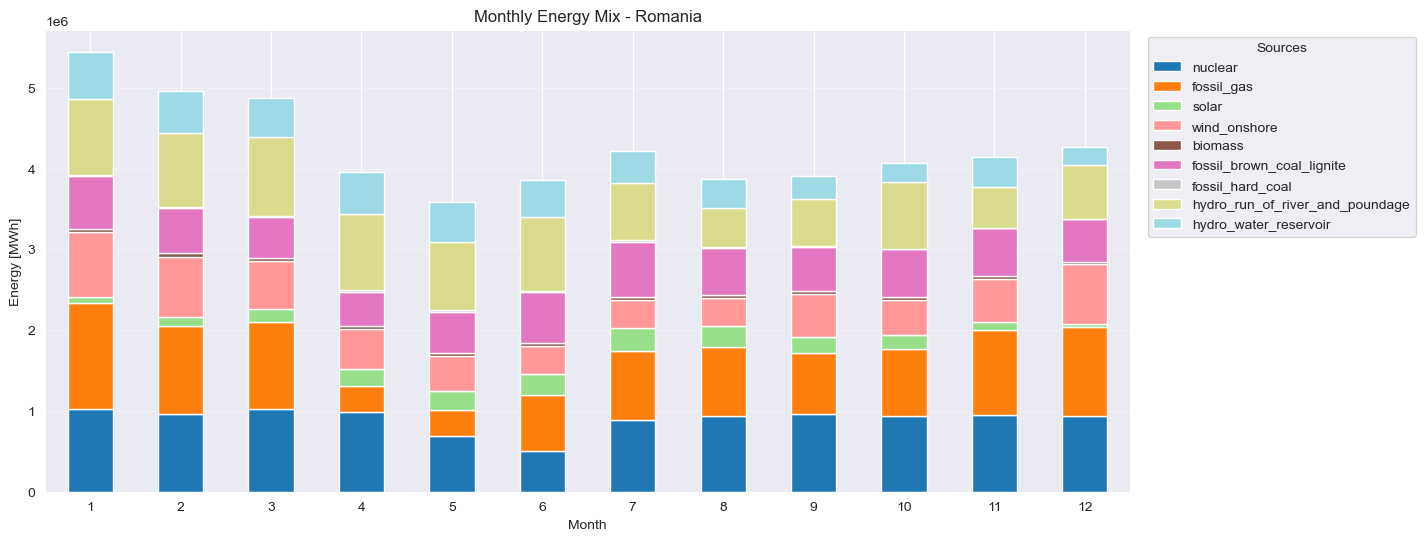

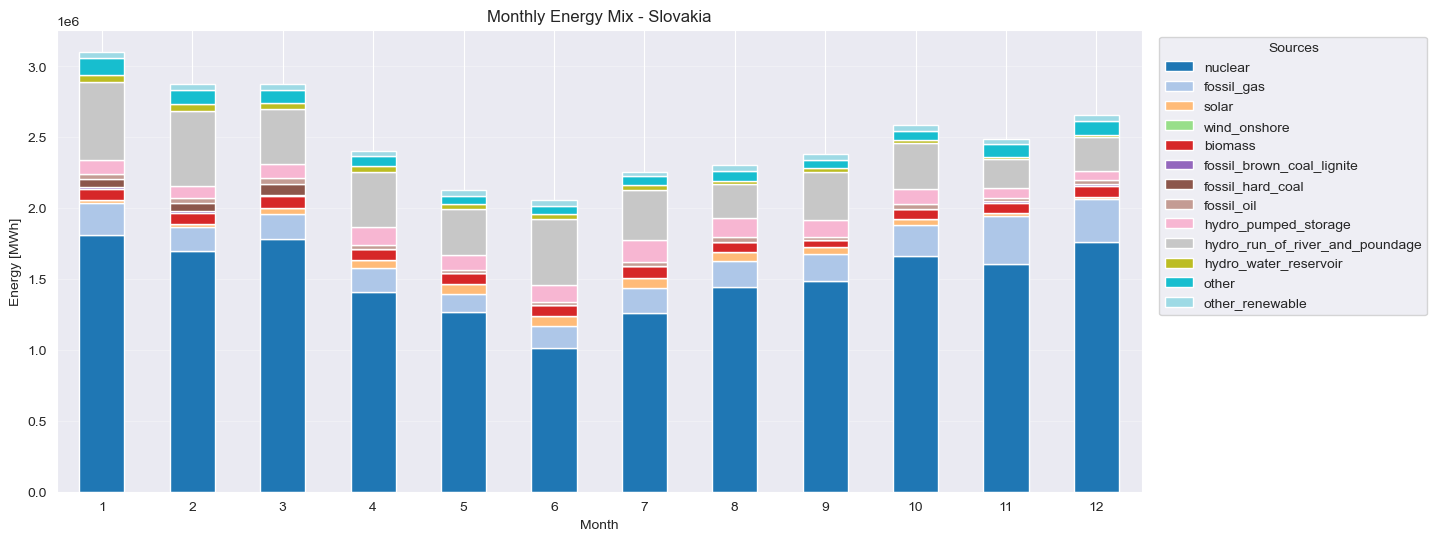

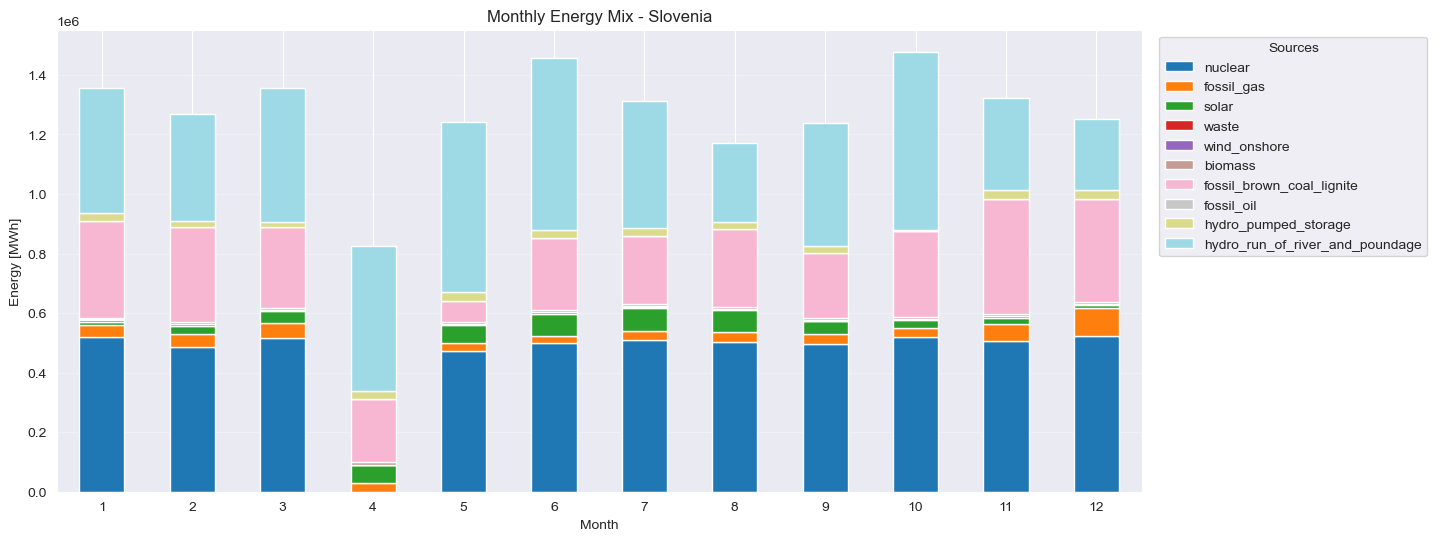

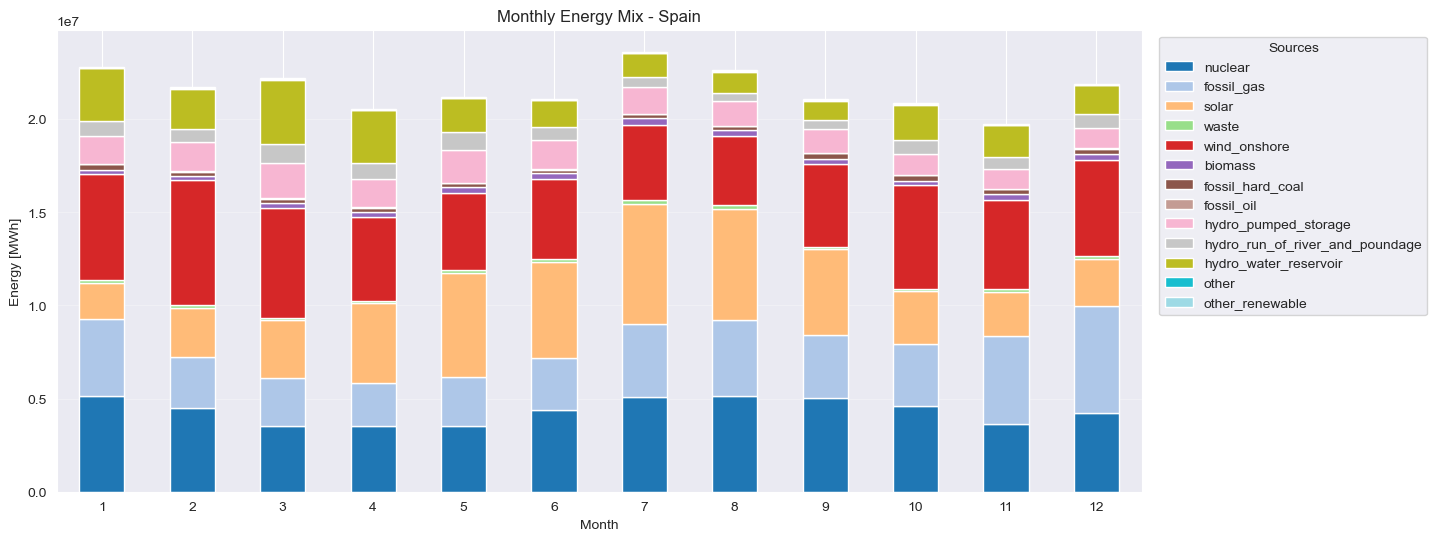

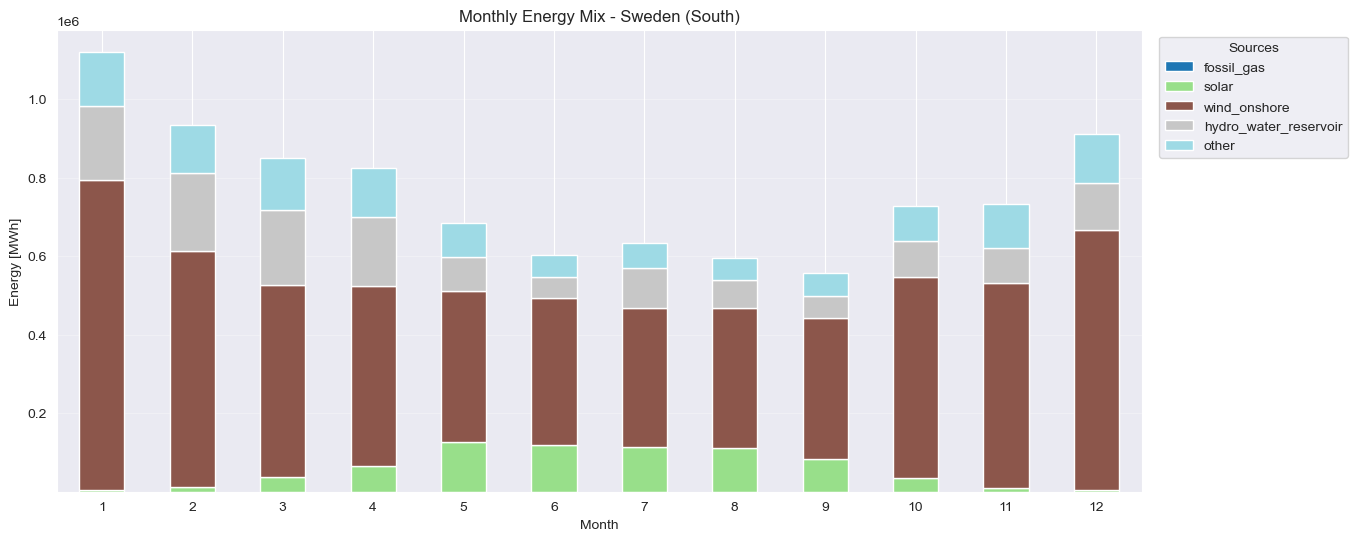

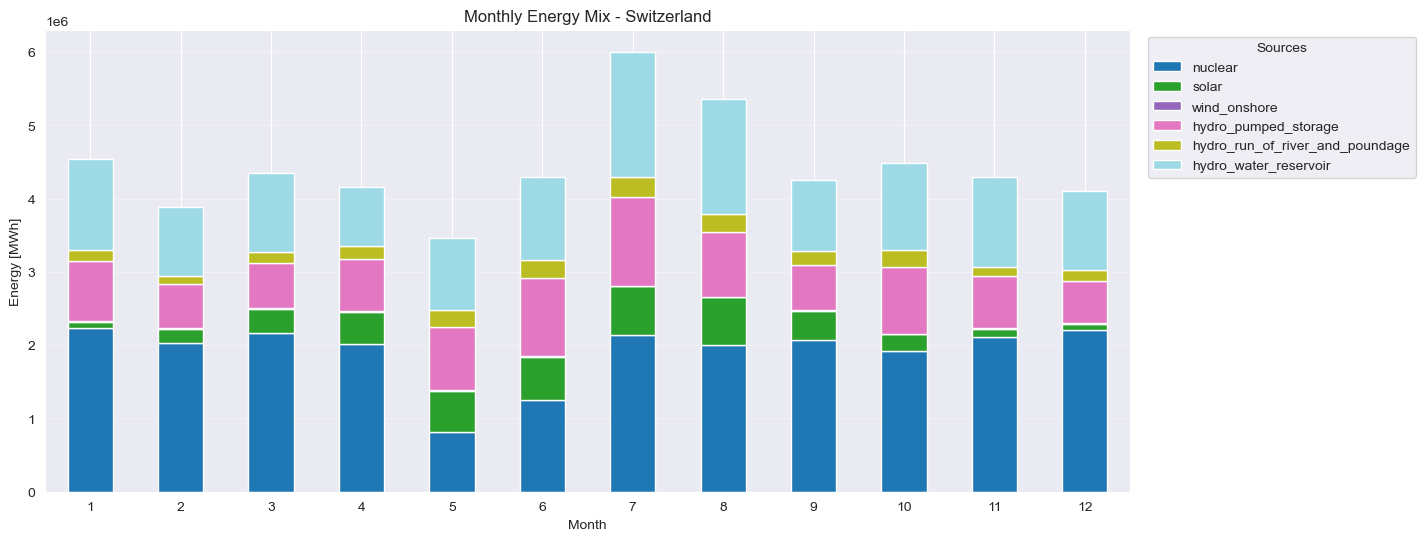

In [26]:
plot_monthly_energy_mix(df2024)